In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import gzip
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

BASE   = '/home/sukhjot/tb_pipeline'
TB_OUT = f'{BASE}/tbprofiler_results'
ML_OUT = f'{BASE}/ml_outputs'

NPZ_PATH = f'{BASE}/intermediate_data/feature_matrix.npz'
GT_PATH = f'{BASE}/intermediate_data/gt_matrix.tsv.gz'
CSV_PATH = f'{BASE}/intermediate_data/variant_matrix_filtered.csv'
VAR_META_PATH = f'{BASE}/variant_metadata.csv'
LABELS_PATH = f'{TB_OUT}/labels.csv'
DR_PATH = f'{TB_OUT}/dr_variants.csv'
COMP_PATH = f'{TB_OUT}/compensatory.csv'
RPOB_PATH = f'{TB_OUT}/rpoB_nonRRDR.csv'
OTHER_PATH = f'{TB_OUT}/other_variants.csv'

print("file paths configured")


file paths configured


In [2]:
pd.set_option('display.max_columns', None)

---
### 1. feature_matrix.npz - The Core Variant Feature Matrix

#### What is it?
A compressed binary matrix in which each **row** is one MTb isolate. Each **column** is 
one genomic variant position. Cell value is **0** (reference allele, same as H37Rv) 
or **1** (alternate allele, differs from H37Rv).

#### How was it made?
```
gt_matrix.tsv.gz  (genotype strings like 0/0, 1/1, 0/1)
   → Python: 0/0 → 0,  1/1 or 0/1 or 1/2 etc → 1
   → numpy uint8 array
   → MAF filter (1% to 99%)
   → malformed variant ID removal
   → np.savez_compressed → feature_matrix.npz
```

#### Why NPZ and not CSV?
- Loads in **seconds** vs 30+ minutes for CSV
- 8× smaller: uint8 = 1 byte per cell vs text "0"/"1" = 2 bytes
- Contains 3 arrays in one file: matrix + sample IDs + variant IDs


In [3]:
print("Loading feature_matrix.npz...")
data     = np.load(NPZ_PATH, allow_pickle=True)
matrix   = data['matrix']
samples  = data['samples'].tolist()
variants = data['variants'].tolist()

print(f"Keys inside NPZ : {list(data.keys())}")
print(f"matrix shape    : {matrix.shape}")
print(f"  → {matrix.shape[0]:,} rows    = MTb isolate samples")
print(f"  → {matrix.shape[1]:,} columns = genomic variant positions")
print(f"dtype           : {matrix.dtype}  (uint8 = values 0 or 1 only)")
print(f"RAM usage       : {matrix.nbytes/1e6:.1f} MB")
print(f"Unique values   : {np.unique(matrix)}  ← confirmed binary")
print()
print(f"Non-zero cells  : {np.count_nonzero(matrix):,}")
print(f"Total cells     : {matrix.size:,}")
print(f"Sparsity        : {(matrix==0).mean()*100:.1f}% zeros")
print(f"  → Expected — most isolates share H37Rv reference at most positions")
print()
print(f"Sample IDs (first 5): {samples[:5]}")
print(f"Variant IDs (first 5): {variants[:5]}")


Loading feature_matrix.npz...
Keys inside NPZ : ['matrix', 'samples', 'variants']
matrix shape    : (1858, 94583)
  → 1,858 rows    = MTb isolate samples
  → 94,583 columns = genomic variant positions
dtype           : uint8  (uint8 = values 0 or 1 only)
RAM usage       : 175.7 MB
Unique values   : [0 1]  ← confirmed binary

Non-zero cells  : 4,524,063
Total cells     : 175,735,214
Sparsity        : 97.4% zeros
  → Expected — most isolates share H37Rv reference at most positions

Sample IDs (first 5): ['SRR11922479', 'SRR11922481', 'SRR11922482', 'SRR11922485', 'SRR11922487']
Variant IDs (first 5): ['Chromosome_30_C_G', 'Chromosome_42_C_T', 'Chromosome_51_C_T,A', 'Chromosome_187_T_C', 'Chromosome_189_A_G,C']


In [ ]:
print("matrix[row_index, col_index]")
print(f"  row  = sample index  (0 to {len(samples)-1})")
print(f"  col  = variant index (0 to {len(variants)-1})")
print()
print(f"Example: matrix[0, 0]")
print(f"  Sample  : {samples[0]}")
print(f"  Variant : {variants[0]}")
print(f"  Value   : {matrix[0,0]}  → {'ALT allele present' if matrix[0,0]==1 else 'Reference allele (same as H37Rv)'}")
print()
print("Top-left 6x6 corner of matrix:")
corner_df = pd.DataFrame(
    matrix[:6, :6],
    index=[s[:12] for s in samples[:6]],
    columns=[v[:22] for v in variants[:6]]
)
print(corner_df.to_string())
print()
print("0 = reference allele (same as H37Rv at this position)")
print("1 = alternate allele (mutation present in this isolate)")


matrix[row_index, col_index]
  row  = sample index  (0 to 1856)
  col  = variant index (0 to 94582)

Example: matrix[0, 0]
  Sample  : SRR11922479
  Variant : Chromosome_30_C_G
  Value   : 0  → Reference allele (same as H37Rv)

Top-left 6×6 corner of matrix:
             Chromosome_30_C_G  Chromosome_42_C_T  Chromosome_51_C_T,A  Chromosome_187_T_C  Chromosome_189_A_G,C  Chromosome_207_T_C
SRR11922479                  0                  0                    0                   0                     0                   0
SRR11922481                  0                  0                    0                   0                     0                   0
SRR11922482                  0                  0                    0                   0                     0                   0
SRR11922485                  0                  0                    0                   0                     0                   0
SRR11922487                  0                  0                    0      

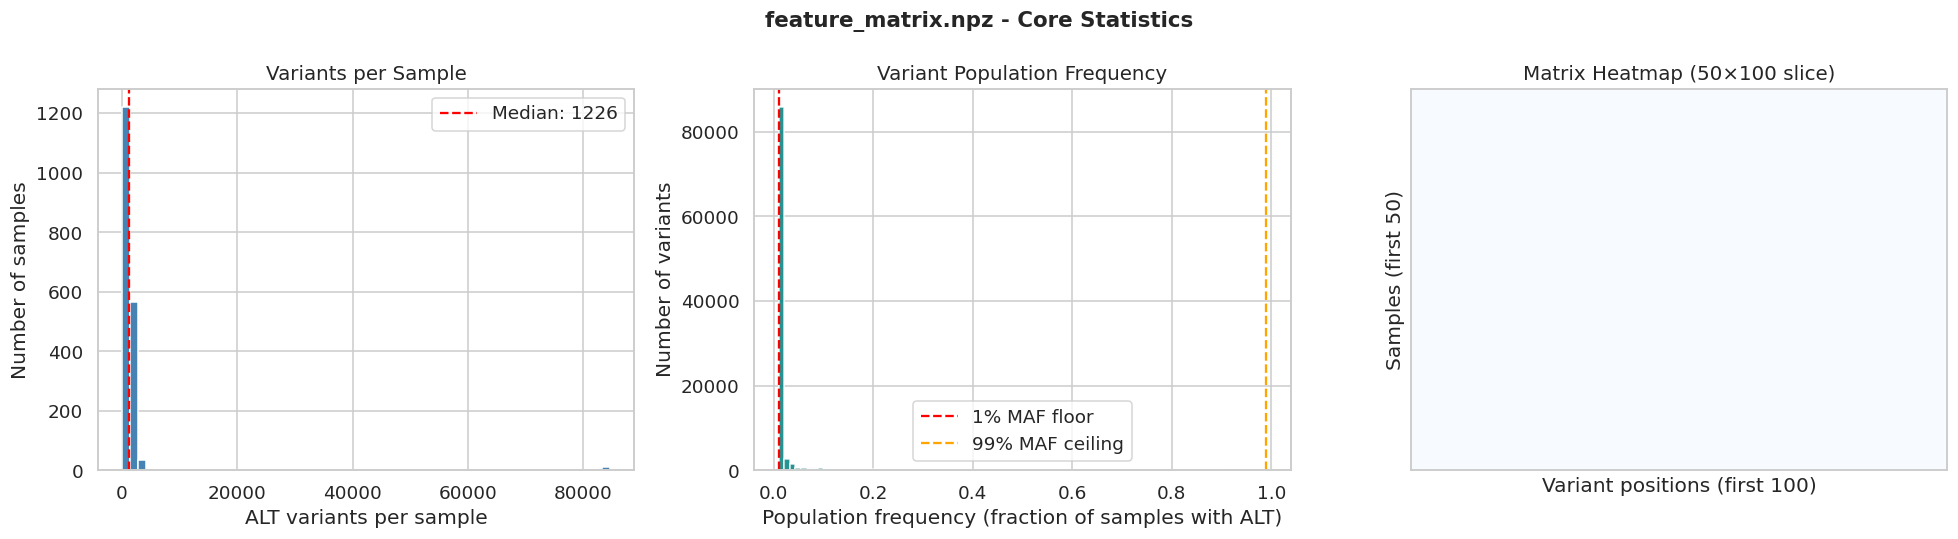

Variants per sample — Min:0 | Max:84558 | Mean:2435 | Median:1226


In [ ]:
sample_var_counts = matrix.sum(axis=1)
var_freq          = matrix.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sample_var_counts, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(np.median(sample_var_counts), color='red', linestyle='--',
                label=f'Median: {np.median(sample_var_counts):.0f}')
axes[0].set_xlabel('ALT variants per sample')
axes[0].set_ylabel('Number of samples')
axes[0].set_title('Variants per Sample')
axes[0].legend()

axes[1].hist(var_freq, bins=80, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(0.01, color='red', linestyle='--', label='1% MAF floor')
axes[1].axvline(0.99, color='orange', linestyle='--', label='99% MAF ceiling')
axes[1].set_xlabel('Population frequency (fraction of samples with ALT)')
axes[1].set_ylabel('Number of variants')
axes[1].set_title('Variant Population Frequency')
axes[1].legend()

axes[2].imshow(matrix[:50, :100], aspect='auto', cmap='Blues', interpolation='none')
axes[2].set_xlabel('Variant positions (first 100)')
axes[2].set_ylabel('Samples (first 50)')
axes[2].set_title('Matrix Heatmap (50×100 slice)')
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.suptitle('feature_matrix.npz - Core Statistics', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Variants per sample — Min:{sample_var_counts.min()} | Max:{sample_var_counts.max()} | Mean:{sample_var_counts.mean():.0f} | Median:{np.median(sample_var_counts):.0f}")


---
#### 2. gt_matrix.tsv.gz - Raw Genotype Table (Pre-Binary Conversion)

#### What is it?
The **intermediate file** produced by `bcftools query` immediately after merging 
all 1,858 VCFs. It contains the raw **genotype strings** (e.g. `0/0`, `1/1`, 
`0/1`) for every sample at every variant position — before conversion to binary.

This is the **direct parent** of `feature_matrix.npz`.

#### How was it made?
```
merged_prefilt.vcf.gz  (multi-sample VCF, MAF-filtered)
   → bcftools query --format '%CHROM_%POS_%REF_%ALT[\t%GT]\n'
   → compressed with bgzip
   → gt_matrix.tsv.gz
```

#### Genotype notation:
| GT string | Meaning | Converted to |
|-----------|---------|--------------|
| `0/0` | Homozygous reference — both alleles match H37Rv | **0** |
| `1/1` | Homozygous alternate — both alleles differ from H37Rv | **1** |
| `0/1` | Heterozygous — one REF, one ALT allele | **1** |
| `2/2`, `3/3` | Second or third alternate allele (multi-allelic) | **1** |
| `./.` | Missing — not enough reads to call genotype | **0** (treated as REF) |

### Why is this kept?
- It is the raw evidence before any conversion decision
- Can be reprocessed with different rules (e.g. treat missing as NaN)
- Audit trail: every 0 and 1 in the NPZ can be traced back here


In [ ]:
print("Reading gt_matrix.tsv.gz header...")
with gzip.open(GT_PATH, 'rt') as f:
    header_line = f.readline().rstrip('\n')
    cols = header_line.split('\t')

print(f"Total columns     : {len(cols):,}")
print(f"First column      : '{cols[0]}'  ← variant_id (merged with first sample ID due to no separator in header)")
print(f"Sample cols (2-6) : {cols[1:6]}")
print(f"Sample cols (last 5): {cols[-5:]}")
print()


with gzip.open(GT_PATH, 'rt') as f:
    n_rows = sum(1 for _ in f) - 1
print(f"Total variant rows: {n_rows:,}  (one per genomic position)")
print(f"Total samples     : {len(cols)-1:,}  (one column per isolate)")
print(f"Total cells       : {n_rows * (len(cols)-1):,}")


Reading gt_matrix.tsv.gz header...
Total columns     : 1,858
First column      : 'variant_idSRR11922476'  ← variant_id (merged with first sample ID due to no separator in header)
Sample cols (2-6) : ['SRR11922479', 'SRR11922481', 'SRR11922482', 'SRR11922485', 'SRR11922487']
Sample cols (last 5): ['SRR5181920', 'SRR5181921', 'SRR5181922', 'SRR5181923', 'SRR5181924']

Total variant rows: 94,583  (one per genomic position)
Total samples     : 1,857  (one column per isolate)
Total cells       : 175,640,631


In [46]:
print("Surveying all GT values across the entire file...")
print("(This reads the full file — may take 1-2 minutes)")

gt_counter   = Counter()
rows_with_alt = 0
n_total_rows  = 0

with gzip.open(GT_PATH, 'rt') as f:
    f.readline()  # skip header
    for line in f:
        parts = line.rstrip('\n').split('\t')
        gts   = parts[1:]
        n_total_rows += 1
        has_alt = False
        for g in gts:
            gt_counter[g] += 1
            if g not in ('0/0', './.', '.', '0|0'):
                has_alt = True
        if has_alt:
            rows_with_alt += 1

print(f"\nVariant positions scanned : {n_total_rows:,}")
print(f"Positions with ALT in ≥1 sample: {rows_with_alt:,}")
print(f"Positions all-reference   : {n_total_rows - rows_with_alt:,}")
print()
print("GT value distribution (most common):")
total_gts = sum(gt_counter.values())
for gt, cnt in gt_counter.most_common(15):
    pct = cnt/total_gts*100
    role = {
        '0/0': '← REF homozygous → converts to 0',
        '1/1': '← ALT homozygous → converts to 1',
        '0/1': '← heterozygous   → converts to 1',
        '2/2': '← 2nd ALT allele → converts to 1',
        '0/2': '← REF + 2nd ALT  → converts to 1',
        './.' : '← missing data   → converts to 0',
    }.get(gt, '← multi-allelic ALT → converts to 1')
    print(f"  {gt!r:<10}: {cnt:>12,}  ({pct:5.4f}%)  {role}")


Surveying all GT values across the entire file...
(This reads the full file — may take 1-2 minutes)



Variant positions scanned : 94,583
Positions with ALT in ≥1 sample: 94,583
Positions all-reference   : 0

GT value distribution (most common):
  '0/0'     :  171,211,151  (97.4256%)  ← REF homozygous → converts to 0
  '1/1'     :    3,753,111  (2.1357%)  ← ALT homozygous → converts to 1
  '0/1'     :      677,623  (0.3856%)  ← heterozygous   → converts to 1
  '2/2'     :       56,360  (0.0321%)  ← 2nd ALT allele → converts to 1
  '0/2'     :       10,438  (0.0059%)  ← REF + 2nd ALT  → converts to 1
  '1/2'     :        9,094  (0.0052%)  ← multi-allelic ALT → converts to 1
  '3/3'     :        8,017  (0.0046%)  ← multi-allelic ALT → converts to 1
  '2/1'     :        5,704  (0.0032%)  ← multi-allelic ALT → converts to 1
  '0/3'     :        1,278  (0.0007%)  ← multi-allelic ALT → converts to 1
  '1/3'     :          802  (0.0005%)  ← multi-allelic ALT → converts to 1
  '3/1'     :          432  (0.0002%)  ← multi-allelic ALT → converts to 1
  '4/4'     :          313  (0.0002%)  ← mult

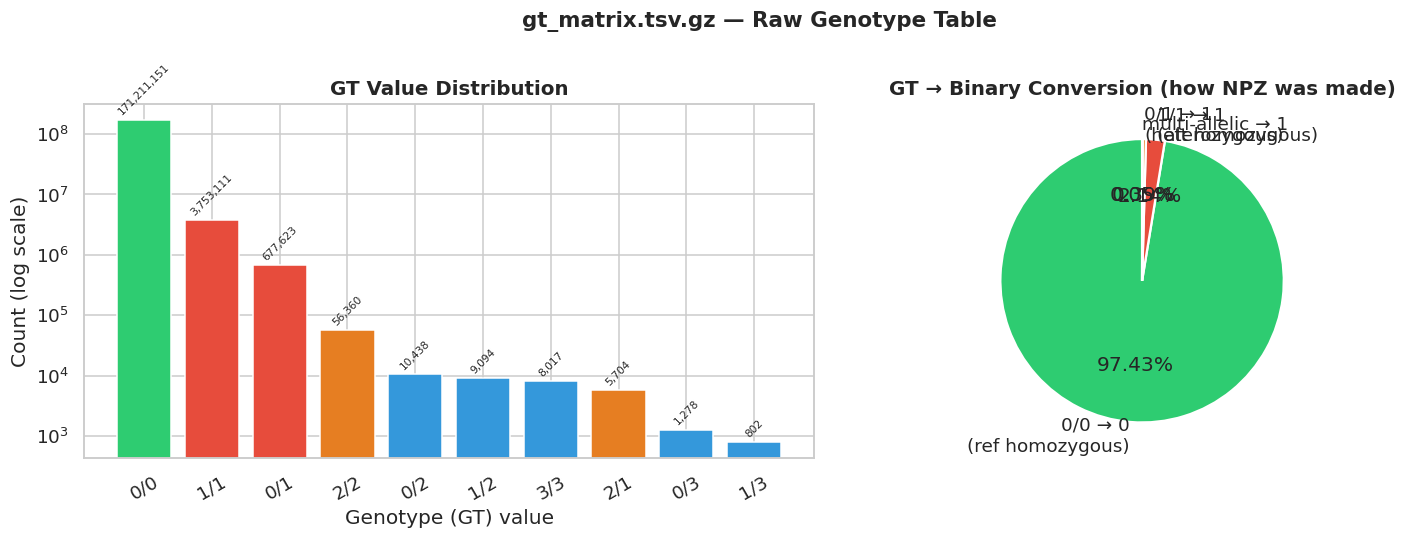


Key insight:
  171,211,151 cells = 0/0 → binary 0
  4,430,734 cells = ALT present → binary 1
  This is the direct source of every value in feature_matrix.npz


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GT distribution bar chart
top_gts = gt_counter.most_common(10)
labels_gt = [g[0] for g in top_gts]
counts_gt = [g[1] for g in top_gts]

colors = ['#2ecc71' if g == '0/0' else
          '#e74c3c' if g in ('1/1','0/1') else
          '#e67e22' if g.startswith('2') else
          '#3498db' for g in labels_gt]

axes[0].bar(labels_gt, counts_gt, color=colors, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel('Genotype (GT) value')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('GT Value Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts_gt):
    axes[0].text(i, v*1.2, f'{v:,.0f}', ha='center', fontsize=7, rotation=45)

# Conversion diagram — FIXED: Replaced raw linebreaks with \n character strings
conversion = {
    '0/0 → 0\n(ref homozygous)': gt_counter.get('0/0',0),
    '1/1 → 1\n(alt homozygous)': gt_counter.get('1/1',0),
    '0/1 → 1\n(heterozygous)' : gt_counter.get('0/1',0),
    'multi-allelic → 1': sum(cnt for gt, cnt in gt_counter.items()
                             if gt not in ('0/0','./.','0/1','1/1','.','')),
    './. → 0\n(missing)': gt_counter.get('./.',0),
}
conv_colors = ['#2ecc71','#e74c3c','#e67e22','#9b59b6','#95a5a6']
axes[1].pie([v for v in conversion.values() if v > 0],
            labels=[k for k,v in conversion.items() if v > 0],
            autopct='%1.2f%%', colors=conv_colors[:len([v for v in conversion.values() if v>0])],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('GT → Binary Conversion (how NPZ was made)', fontweight='bold')

plt.suptitle('gt_matrix.tsv.gz — Raw Genotype Table', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nKey insight:")
print(f"  {gt_counter.get('0/0',0):,} cells = 0/0 → binary 0")
print(f"  {gt_counter.get('1/1',0) + gt_counter.get('0/1',0):,} cells = ALT present → binary 1")
print(f"  This is the direct source of every value in feature_matrix.npz")

---
### 3. variant_matrix_filtered.csv - Binary Matrix (CSV Format)

#### What is it?
The **CSV version** of the binary variant matrix - produced by the merge 
pipeline before Step 1 ran. It contains the same 0/1 data as the NPZ but:
- Has **126,856 variant columns** (vs 94,583 in NPZ)
- Contains **malformed column names** (single letters like `A`, `C`, `T`, `G`)
- Has already applied MAF 1-99% filter

#### How was it made?
```
gt_matrix.tsv.gz
   → Python: GT strings → 0/1 binary
   → MAF filter (1-99%) applied
   → Written as CSV row by row
   → variant_matrix_filtered.csv
```

#### Why does it have MORE variants than the NPZ?
```
variant_matrix_filtered.csv  →  126,856 variant columns
feature_matrix.npz           →   94,583 variant columns
Difference                   →   32,273 columns
```
**31,951 malformed single-character column names** (`A`, `C`, 
`T`, `G` etc.) that came from bcftools header parsing artifacts. These were 
removed, producing the clean NPZ.

#### When to use this vs the NPZ?
- **Always use NPZ** for ML and analysis - it is clean
- Use this CSV only for **auditing** or if a tool cannot read `.npy` format
- **Do not load into pandas** - 1857 × 126,856 will take 30+ minutes


In [38]:
print("Reading variant_matrix_filtered.csv (header only — full load would take 30+ min)...")

with open(CSV_PATH) as f:
    header = f.readline().rstrip('\n').split(',')
    first_5_rows = []
    for i, line in enumerate(f):
        if i >= 5: break
        first_5_rows.append(line.rstrip('\n').split(','))

n_cols     = len(header) - 1   # exclude sample_id column
n_rows     = sum(1 for _ in open(CSV_PATH)) - 1

print(f"Total samples  : {n_rows:,}  (rows)")
print(f"Total variants : {n_cols:,}  (columns)")
print(f"Total cells    : {n_rows * n_cols:,}")
print()
print(f"First column   : '{header[0]}'  (sample ID)")
print(f"Variant cols (2-6): {header[1:6]}")
print(f"Variant cols (last 5): {header[-5:]}")
print()
print("First 5 rows (first 7 cols):")
preview_df = pd.DataFrame(
    first_5_rows,
    columns=header[:7]
)[header[:7]]
print(preview_df.to_string(index=False))


Reading variant_matrix_filtered.csv (header only — full load would take 30+ min)...


Total samples  : 1,857  (rows)
Total variants : 126,856  (columns)
Total cells    : 235,571,592

First column   : 'sample_id'  (sample ID)
Variant cols (2-6): ['Chromosome_30_C_G', 'Chromosome_42_C_T', 'Chromosome_51_C_T', 'A', 'Chromosome_187_T_C']
Variant cols (last 5): ['Chromosome_4411016_G_A', 'Chromosome_4411067_C_T', 'Chromosome_4411092_C_T', 'Chromosome_4411102_T_G', 'Chromosome_4411106_C_A']

First 5 rows (first 7 cols):


ValueError: 7 columns passed, passed data had 94584 columns

In [39]:
variant_cols = header[1:]

single_char  = [c for c in variant_cols if len(c.strip()) <= 2]
valid_cols   = [c for c in variant_cols if len(c.strip()) > 2 and ',' not in c]
comma_cols   = [c for c in variant_cols if ',' in c]

print("=== COLUMN QUALITY ANALYSIS ===")
print(f"Total variant columns  : {len(variant_cols):,}")
print()
print(f"Valid (Chromosome_POS_REF_ALT) : {len(valid_cols):,}  ← these are kept")
print(f"Single/short char (malformed)  : {len(single_char):,}  ← REMOVED in Step 1")
print(f"Multi-allelic (comma in ALT)   : {len(comma_cols):,}  ← FIXED in Step 1 (first ALT kept)")
print()
print(f"Malformed examples: {single_char[:15]}")
print()
print("=== COMPARISON WITH NPZ ===")

npz_data     = np.load(NPZ_PATH, allow_pickle=True)
npz_variants = len(npz_data['variants'])
print(f"variant_matrix_filtered.csv : {len(variant_cols):,} variants")
print(f"feature_matrix.npz          : {npz_variants:,} variants")
print(f"Difference                  : {len(variant_cols) - npz_variants:,} columns")
print(f"  ({len(single_char):,} malformed single-char removed + small rounding from dedup)")
print()
print("Conclusion: NPZ is the CLEAN version. Always use NPZ for analysis.")


=== COLUMN QUALITY ANALYSIS ===
Total variant columns  : 126,856

Valid (Chromosome_POS_REF_ALT) : 94,905  ← these are kept
Single/short char (malformed)  : 31,951  ← REMOVED in Step 1
Multi-allelic (comma in ALT)   : 0  ← FIXED in Step 1 (first ALT kept)

Malformed examples: ['A', 'C', 'C', 'A', 'G', 'G', 'A', 'T', 'G', 'T', 'G', 'A', 'T', 'C', 'C']

=== COMPARISON WITH NPZ ===
variant_matrix_filtered.csv : 126,856 variants
feature_matrix.npz          : 94,583 variants
Difference                  : 32,273 columns
  (31,951 malformed single-char removed + small rounding from dedup)

Conclusion: NPZ is the CLEAN version. Always use NPZ for analysis.


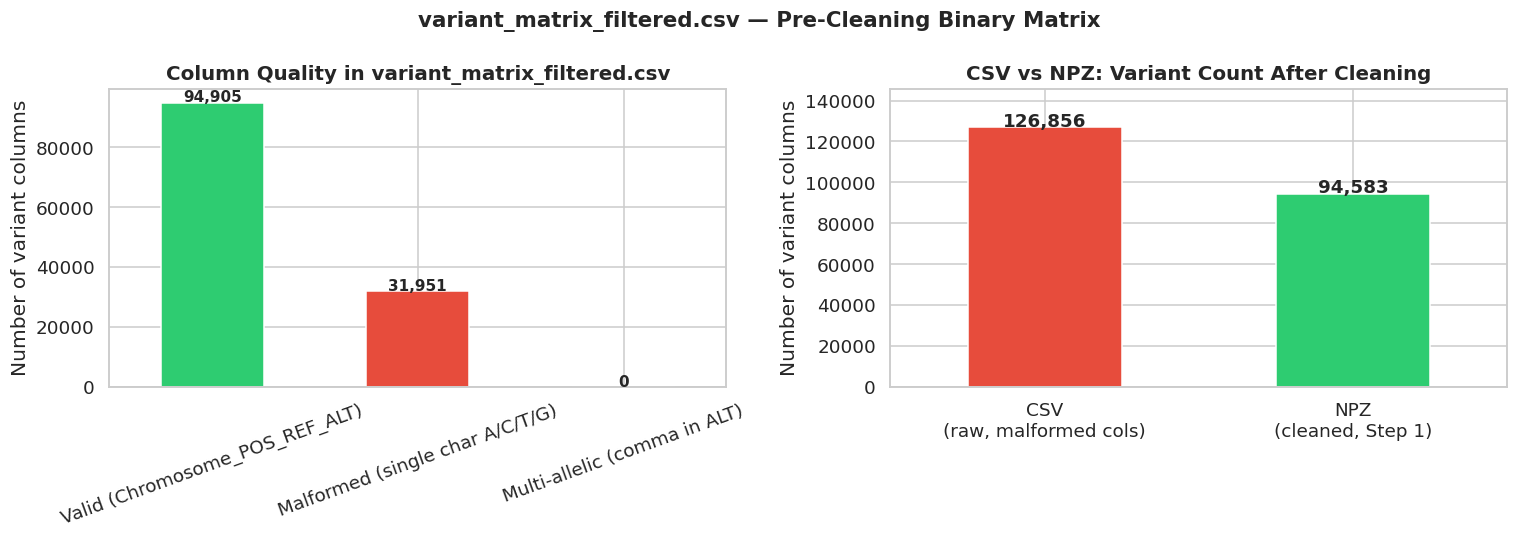

In [40]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Column type breakdown
col_types = pd.Series({
    'Valid (Chromosome_POS_REF_ALT)': len(valid_cols),
    'Malformed (single char A/C/T/G)': len(single_char),
    'Multi-allelic (comma in ALT)': len(comma_cols),
})
colors = ['#2ecc71','#e74c3c','#e67e22']
col_types.plot.bar(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Column Quality in variant_matrix_filtered.csv', fontweight='bold')
axes[0].set_ylabel('Number of variant columns')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(col_types.values):
    axes[0].text(i, v+200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# CSV vs NPZ comparison
comparison = pd.Series({
    'CSV\n(raw, malformed cols)': len(variant_cols),
    'NPZ\n(cleaned, Step 1)': npz_variants
})
bar_colors = ['#e74c3c','#2ecc71']
comparison.plot.bar(ax=axes[1], color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('CSV vs NPZ: Variant Count After Cleaning', fontweight='bold')
axes[1].set_ylabel('Number of variant columns')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(comparison.values):
    axes[1].text(i, v+200, f'{v:,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(comparison.values) * 1.15)

plt.suptitle('variant_matrix_filtered.csv — Pre-Cleaning Binary Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


---
### 4. labels.csv - Drug Resistance Labels for Every Sample

#### What is it?
One row per sample, Contains the complete drug resistance profile from TB-Profiler and
serves as the **ground truth** for ML model training.

#### How was it made?
```
Per-sample filtered VCF (QUAL≥20, DP≥4)
   → TB-Profiler (who_v2+ database)  → JSON per sample
   → collate_tbprofiler.py           → labels.csv
```

#### Column groups:
| Group | Columns | Purpose |
|-------|---------|---------|
| Identity | `sample_id, drtype` | Sample ID and WHO resistance class |
| Lineage | `main_lineage, sub_lineage` | MTb evolutionary lineage |
| **ML targets** | `MDR, pre_XDR, XDR` | Binary flags — what models predict |
| RRDR flag | `has_rpoB_RRDR` | Confirms primary rifampicin resistance |
| Per-drug (R/S) | `rifampicin ... cycloserine` | 20 drug resistance calls |
| Per-drug (binary) | `rifampicin_binary ... cycloserine_binary` | Same as 0/1 |


In [4]:
labels = pd.read_csv(LABELS_PATH)
print(f"Shape: {labels.shape}")
print()
print("all columns:")
for i, c in enumerate(labels.columns):
    print(f"  [{i}] {c}")


Shape: (1858, 49)

all columns:
  [0] sample_id
  [1] drtype
  [2] main_lineage
  [3] sub_lineage
  [4] MDR
  [5] pre_XDR
  [6] XDR
  [7] has_rpoB_RRDR
  [8] total_variants_qc
  [9] rifampicin
  [10] rifapentine
  [11] isoniazid
  [12] ethambutol
  [13] pyrazinamide
  [14] moxifloxacin
  [15] levofloxacin
  [16] bedaquiline
  [17] delamanid
  [18] pretomanid
  [19] linezolid
  [20] streptomycin
  [21] amikacin
  [22] kanamycin
  [23] capreomycin
  [24] clofazimine
  [25] ethionamide
  [26] prothionamide
  [27] para-aminosalicylic_acid
  [28] cycloserine
  [29] rifampicin_binary
  [30] rifapentine_binary
  [31] isoniazid_binary
  [32] ethambutol_binary
  [33] pyrazinamide_binary
  [34] moxifloxacin_binary
  [35] levofloxacin_binary
  [36] bedaquiline_binary
  [37] delamanid_binary
  [38] pretomanid_binary
  [39] linezolid_binary
  [40] streptomycin_binary
  [41] amikacin_binary
  [42] kanamycin_binary
  [43] capreomycin_binary
  [44] clofazimine_binary
  [45] ethionamide_binary
  [46] p

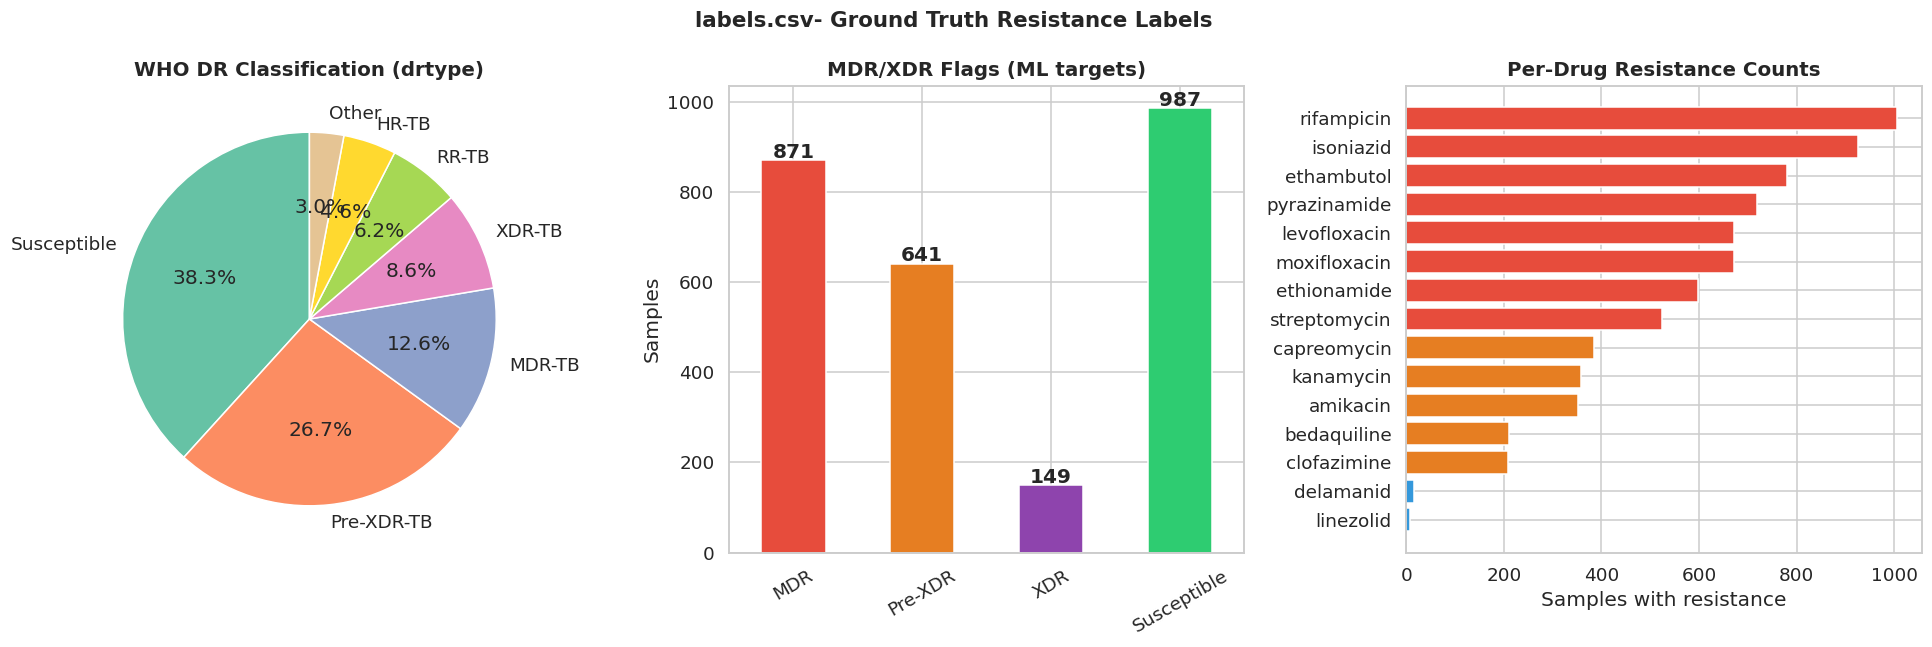

MDR: 871 | Pre-XDR: 641 | XDR: 149
has_rpoB_RRDR: 976 samples
Null lineages: 41


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

labels['drtype'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%',
    colors=sns.color_palette('Set2', labels['drtype'].nunique()),
    startangle=90)
axes[0].set_title('WHO DR Classification (drtype)', fontweight='bold')
axes[0].set_ylabel('')


flags = pd.Series({
    'MDR': labels['MDR'].sum(),
    'Pre-XDR': labels['pre_XDR'].sum(),
    'XDR': labels['XDR'].sum(),
    'Susceptible': (labels['MDR']==0).sum()
})
flags.plot.bar(ax=axes[1], color=['#e74c3c','#e67e22','#8e44ad','#2ecc71'], edgecolor='white')
axes[1].set_title('MDR/XDR Flags (ML targets)', fontweight='bold')
axes[1].set_ylabel('Samples')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(flags.values):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')


drugs = ['rifampicin','isoniazid','ethambutol','pyrazinamide','moxifloxacin', 'streptomycin','amikacin','kanamycin','ethionamide','bedaquiline', 'capreomycin','levofloxacin','clofazimine','linezolid','delamanid']
drug_r = [(d, (labels[d]=='R').sum()) for d in drugs if d in labels.columns]
drug_df = pd.DataFrame(drug_r, columns=['drug','count']).sort_values('count', ascending=True)
axes[2].barh(drug_df['drug'], drug_df['count'],
             color=['#e74c3c' if v>400 else '#e67e22' if v>150 else '#3498db'
                    for v in drug_df['count']])
axes[2].set_title('Per-Drug Resistance Counts', fontweight='bold')
axes[2].set_xlabel('Samples with resistance')

plt.suptitle('labels.csv- Ground Truth Resistance Labels', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"MDR: {labels['MDR'].sum()} | Pre-XDR: {labels['pre_XDR'].sum()} | XDR: {labels['XDR'].sum()}")
print(f"has_rpoB_RRDR: {labels['has_rpoB_RRDR'].sum()} samples")
print(f"Null lineages: {labels['main_lineage'].isnull().sum()}")


---
### 5. dr_variants.csv - Known Drug Resistance Mutations

#### What is it?
Every variant TB-Profiler identified as a known resistance mutation across 
all samples, one row per variant-sample-drug combination.

#### Key columns:
- `gene, change` - the specific mutation (e.g. rpoB p.Ser450Leu)
- `drug` - which drug this confers resistance to
- `confidence` - WHO evidence level
- `is_RRDR` - 1 if rpoB mutation is inside the RRDR (codons 426-452, primary resistance)
- `freq, depth` - allele frequency and read depth


In [29]:
dr = pd.read_csv(DR_PATH)
print(f"shape: {dr.shape}")
print(f"unique samples: {dr['sample_id'].nunique()}")
print()
print("sample rows:")
print(dr[['sample_id','gene','change','drug','confidence','is_RRDR','freq','depth']].head(8).to_string(index=False))
print()
print("WHO Confidence distribution:")
for conf, cnt in dr['confidence'].value_counts().items():
    flag = ' - COUNTS AS RESISTANT' if 'Assoc w R' in conf and 'Not' not in conf else ''
    print(f"  {conf:<35}: {cnt:>5,}  {flag}")


shape: (14734, 14)
unique samples: 1147

sample rows:
  sample_id gene      change          drug             confidence  is_RRDR     freq  depth
SRR11947327 ethR p.Phe110Leu   ethionamide Uncertain significance        0 1.018519     54
SRR11947327 ethR p.Phe110Leu   ethionamide Uncertain significance        0 1.018519     54
SRR11947327 ethR p.Phe110Leu prothionamide Uncertain significance        0 1.018519     54
SRR11947335  gid   c.351dupG  streptomycin              Assoc w R        0 0.923567    157
SRR11947499 ethR  p.Ala95Thr   ethionamide Uncertain significance        0 1.000000    193
SRR11947499 ethR  p.Ala95Thr   ethionamide Uncertain significance        0 1.000000    193
SRR11947499 ethR  p.Ala95Thr prothionamide Uncertain significance        0 1.000000    193
SRR11947508 rpsL  p.Lys43Arg  streptomycin              Assoc w R        0 1.007692    130

WHO Confidence distribution:
  Assoc w R                          : 8,353   - COUNTS AS RESISTANT
  Uncertain significance    

In [32]:
dr.head()

,sample_id,gene,locus_tag,change,nucleotide_change,type,drug,confidence,depth,freq,pos,is_RRDR,sample_MDR,sample_drtype
0,SRR11947327,ethR,Rv3855,p.Phe110Leu,c.328T>C,missense_variant,ethionamide,Uncertain significance,54,1.018519,4327876,0,0,Other
1,SRR11947327,ethR,Rv3855,p.Phe110Leu,c.328T>C,missense_variant,ethionamide,Uncertain significance,54,1.018519,4327876,0,0,Other
2,SRR11947327,ethR,Rv3855,p.Phe110Leu,c.328T>C,missense_variant,prothionamide,Uncertain significance,54,1.018519,4327876,0,0,Other
3,SRR11947335,gid,Rv3919c,c.351dupG,c.351dupG,frameshift_variant,streptomycin,Assoc w R,157,0.923567,4407851,0,0,Other
4,SRR11947499,ethR,Rv3855,p.Ala95Thr,c.283G>A,missense_variant,ethionamide,Uncertain significance,193,1.000000,4327831,0,0,Other


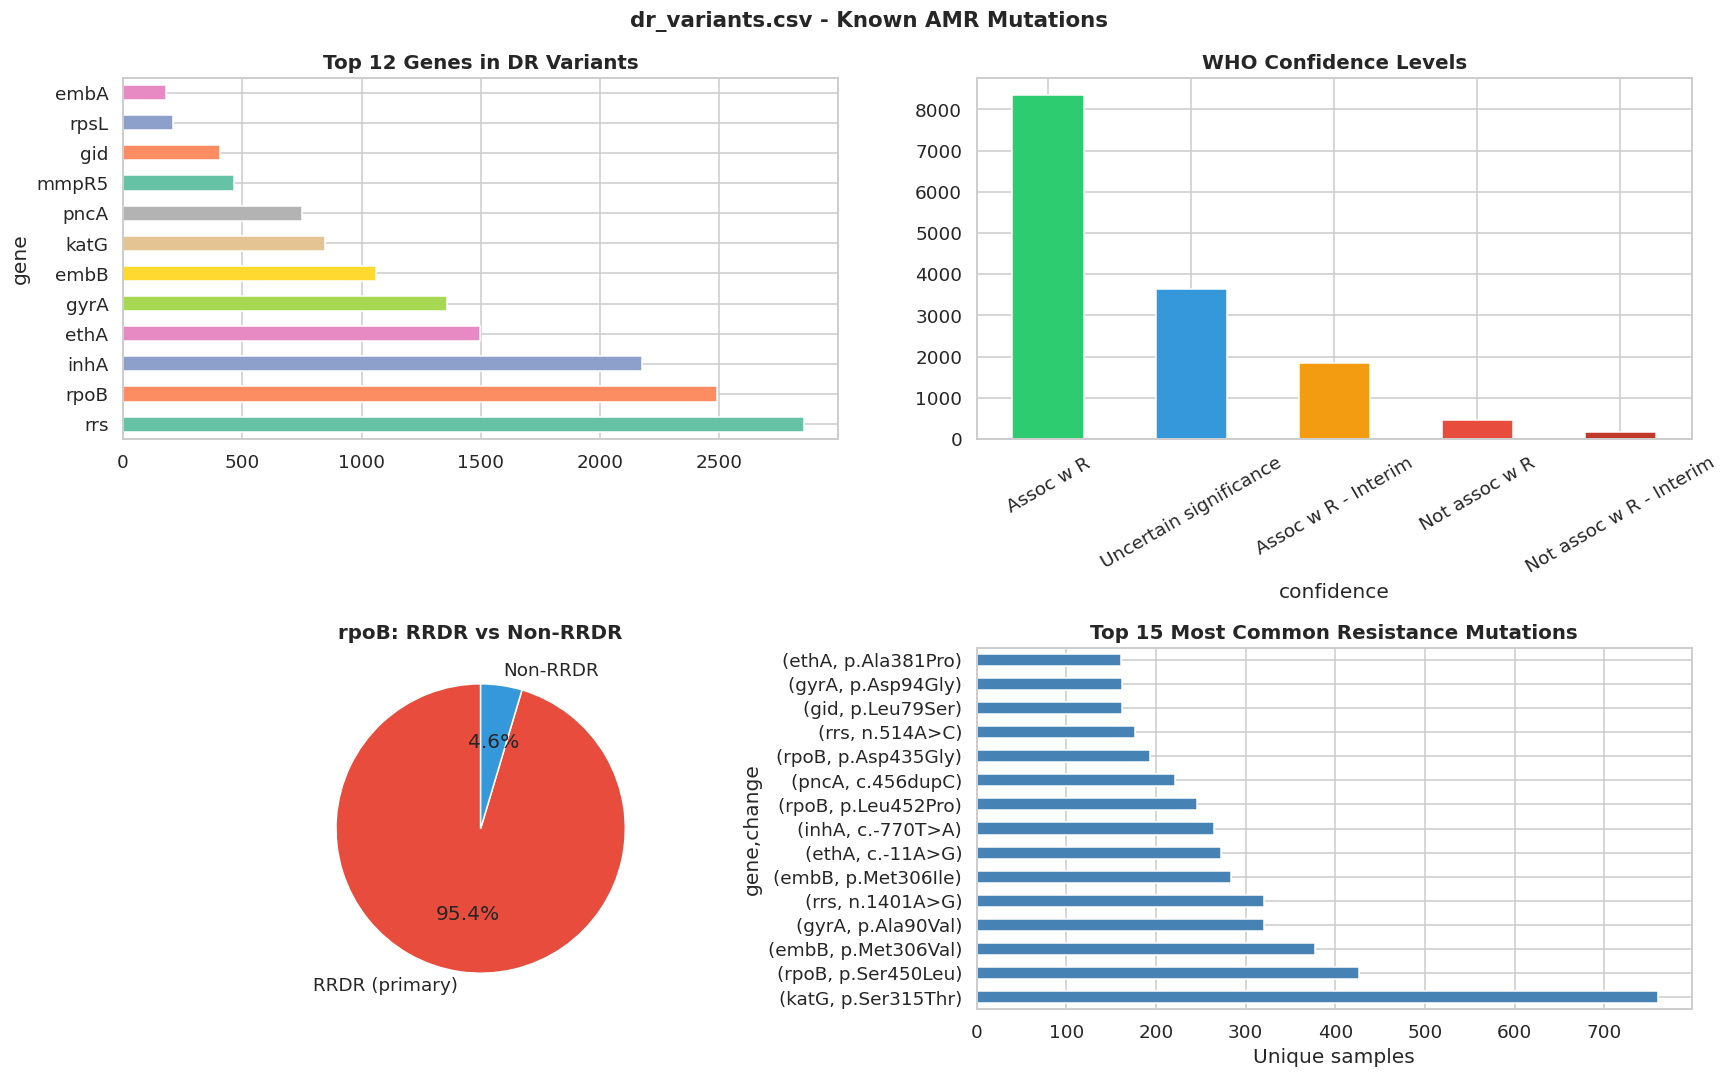

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

dr['gene'].value_counts().head(12).plot.barh(
    ax=axes[0,0], color=sns.color_palette('Set2',12))
axes[0,0].set_title('Top 12 Genes in DR Variants', fontweight='bold')

conf_colors = {'Assoc w R':'#2ecc71','Assoc w R - Interim':'#f39c12', 'Uncertain significance':'#3498db','Not assoc w R':'#e74c3c', 'Not assoc w R - Interim':'#c0392b'}
conf_counts = dr['confidence'].value_counts()
[conf_colors.get(c,'grey') for c in conf_counts.index]
conf_counts.plot.bar(ax=axes[0,1],
    color=[conf_colors.get(c,'grey') for c in conf_counts.index], edgecolor='white')
axes[0,1].set_title('WHO Confidence Levels', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)

rpob_dr = dr[dr['gene']=='rpoB']
rrdr_counts = rpob_dr['is_RRDR'].map({1:'RRDR (primary)',0:'Non-RRDR'}).value_counts()
axes[1,0].pie(rrdr_counts.values, labels=rrdr_counts.index,
    autopct='%1.1f%%', colors=['#e74c3c','#3498db'], startangle=90)
axes[1,0].set_title('rpoB: RRDR vs Non-RRDR', fontweight='bold')

dr.groupby(['gene','change'])['sample_id'].nunique().nlargest(15).plot.barh(
    ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Top 15 Most Common Resistance Mutations', fontweight='bold')
axes[1,1].set_xlabel('Unique samples')

plt.suptitle('dr_variants.csv - Known AMR Mutations', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
### 6. compensatory.csv - Candidate Compensatory Mutations
#### Critical rule:
only records where `sample_MDR = 1` are true compensatory candidates and   
records where `sample_MDR = 0` are background polymorphisms kept for comparison.

#### Genes included and biological reason:
| Gene | Compensates | Mechanism |
|------|------------|-----------|
| rpoA, rpoC | rpoB RRDR mutations | Restore RNA polymerase efficiency |
| ahpC, kasA, ndh | katG/inhA mutations | Restore oxidative defence |
| gyrB | gyrA QRDR mutations | Restore DNA gyrase supercoiling |
| gid | rpsL/rrs mutations | Restore ribosome fitness |
| mmpL5, mmpR5 | BDQ/CFZ efflux | Modulate drug efflux pump |
| embR | embB mutations | Restore arabinogalactan synthesis |
| whiB7, eis | Broad MDR fitness | General fitness restoration |


In [23]:

comp = pd.read_csv(COMP_PATH)
print(f"shape: {comp.shape}")
print(f"unique samples: {comp['sample_id'].nunique()}")
print(f"unique genes  : {comp['gene'].nunique()}")
print()
print("MDR context split:")
for v, cnt in comp['sample_MDR'].value_counts().items():
    label = 'TRUE compensatory context' if v==1 else 'background — non-MDR samples'
    print(f"  sample_MDR={v}: {cnt}  ← {label}")

print()
print("Gene breakdown:")
for gene, cnt in comp['gene'].value_counts().items():
    mdr_cnt = comp[(comp['gene']==gene)&(comp['sample_MDR']==1)].shape[0]
    print(f"  {gene}: {cnt} total  ({mdr_cnt} in MDR context)")


shape: (24718, 21)
unique samples: 1274
unique genes  : 13

MDR context split:
  sample_MDR=0: 17494  ← background — non-MDR samples
  sample_MDR=1: 7224  ← TRUE compensatory context

Gene breakdown:
  rpoC: 13713 total  (1692 in MDR context)
  rpoA: 5577 total  (291 in MDR context)
  rpoB: 1335 total  (1148 in MDR context)
  mmpL5: 1335 total  (1335 in MDR context)
  gid: 1014 total  (1014 in MDR context)
  kasA: 490 total  (490 in MDR context)
  embR: 411 total  (411 in MDR context)
  gyrB: 298 total  (298 in MDR context)
  ndh: 255 total  (255 in MDR context)
  ahpC: 120 total  (120 in MDR context)
  mmpR5: 93 total  (93 in MDR context)
  whiB7: 48 total  (48 in MDR context)
  eis: 29 total  (29 in MDR context)


In [21]:
comp.head()

,sample_id,gene,locus_tag,change,nucleotide_change,type,depth,freq,pos,is_compensatory_candidate,compensatory_mechanism,drug_context,evidence,sample_MDR,sample_pre_XDR,sample_XDR,sample_drtype,sample_lineage,drugs_annotated,confidences_annotated,requires_MDR_context
0,SRR11922481,rpoC,Rv0668,c.1626C>G,c.1626C>G,synonymous_variant,143,1.013986,764995,1,Beta-prime subunit of RNA polymerase. Mutation...,rifampicin,Comas et al. 2012 Nat Genet; Muller et al. 2017,0,0,0,Susceptible,lineage4,rifampicin|rifapentine,Not assoc w R|Not assoc w R,0
1,SRR11922481,rpoC,Rv0668,c.3117A>G,c.3117A>G,synonymous_variant,99,1.000000,766486,1,Beta-prime subunit of RNA polymerase. Mutation...,rifampicin,Comas et al. 2012 Nat Genet; Muller et al. 2017,0,0,0,Susceptible,lineage4,rifampicin|rifapentine,Uncertain significance|Uncertain significance,0
2,SRR11922485,rpoC,Rv0668,c.1626C>G,c.1626C>G,synonymous_variant,118,1.000000,764995,1,Beta-prime subunit of RNA polymerase. Mutation...,rifampicin,Comas et al. 2012 Nat Genet; Muller et al. 2017,0,0,0,Susceptible,lineage4,rifampicin|rifapentine,Not assoc w R|Not assoc w R,0
3,SRR11922490,rpoC,Rv0668,c.1626C>G,c.1626C>G,synonymous_variant,36,1.000000,764995,1,Beta-prime subunit of RNA polymerase. Mutation...,rifampicin,Comas et al. 2012 Nat Genet; Muller et al. 2017,0,0,0,Susceptible,lineage4,rifampicin|rifapentine,Not assoc w R|Not assoc w R,0
4,SRR11922503,rpoC,Rv0668,c.1626C>G,c.1626C>G,synonymous_variant,37,1.000000,764995,1,Beta-prime subunit of RNA polymerase. Mutation...,rifampicin,Comas et al. 2012 Nat Genet; Muller et al. 2017,0,0,0,Susceptible,lineage4,rifampicin|rifapentine,Not assoc w R|Not assoc w R,0


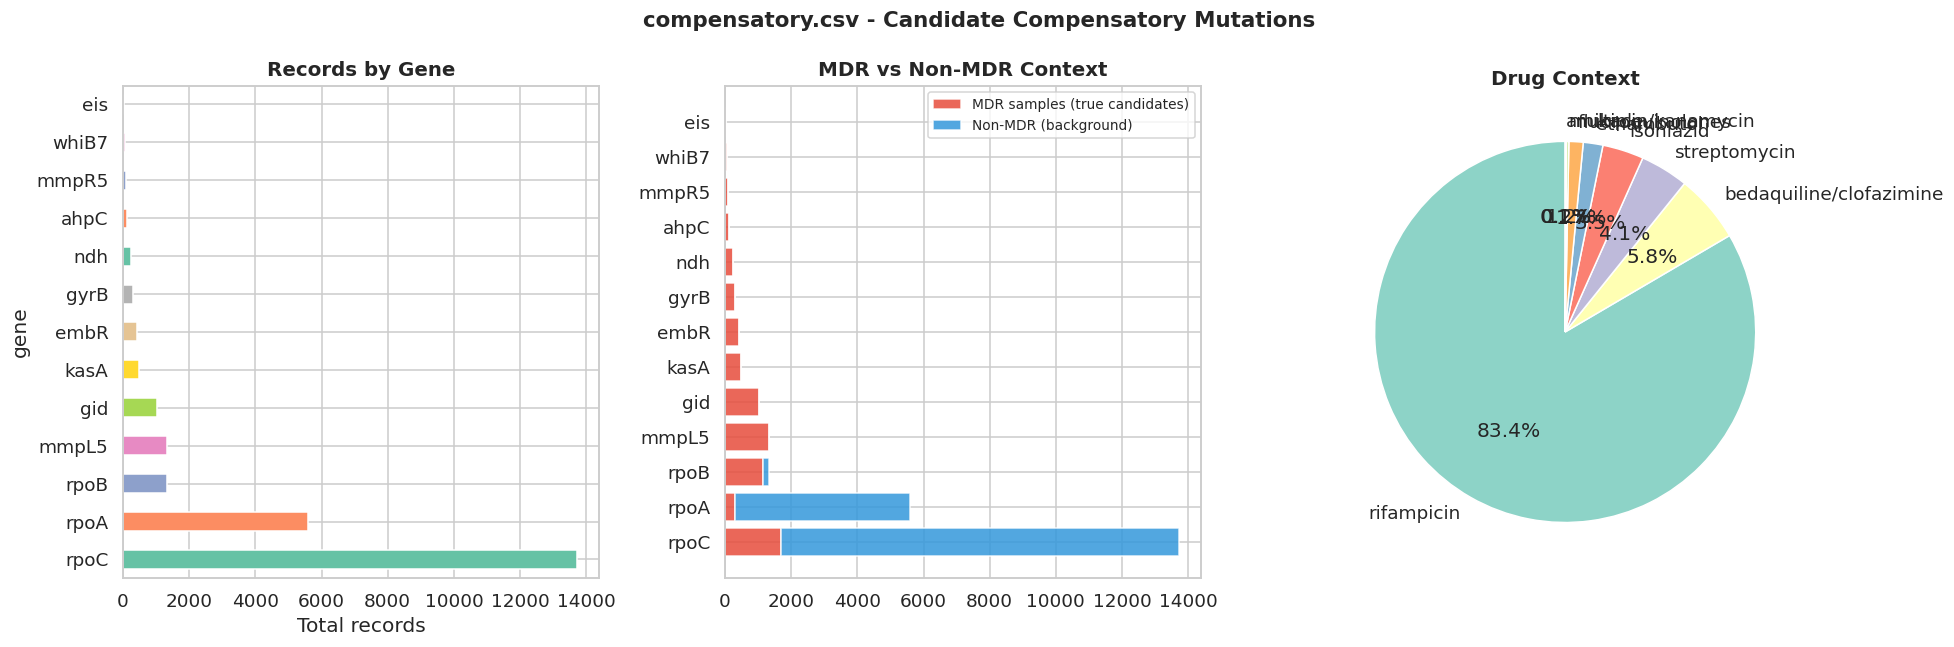

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

comp['gene'].value_counts().plot.barh(
    ax=axes[0], color=sns.color_palette('Set2', comp['gene'].nunique()))
axes[0].set_title('Records by Gene', fontweight='bold')
axes[0].set_xlabel('Total records')

comp_mdr  = comp[comp['sample_MDR']==1]['gene'].value_counts()
comp_susc = comp[comp['sample_MDR']==0]['gene'].value_counts()
genes_all = comp['gene'].value_counts().index.tolist()
axes[1].barh(genes_all, [comp_mdr.get(g,0) for g in genes_all],
             label='MDR samples (true candidates)', color='#e74c3c', alpha=0.85)
axes[1].barh(genes_all, [comp_susc.get(g,0) for g in genes_all],
             left=[comp_mdr.get(g,0) for g in genes_all],
             label='Non-MDR (background)', color='#3498db', alpha=0.85)
axes[1].set_title('MDR vs Non-MDR Context', fontweight='bold')
axes[1].legend(fontsize=9)

comp['drug_context'].value_counts().plot.pie(
    ax=axes[2], autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('Set3', comp['drug_context'].nunique()))
axes[2].set_title('Drug Context', fontweight='bold')
axes[2].set_ylabel('')

plt.suptitle('compensatory.csv - Candidate Compensatory Mutations', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


---
### 7. rpoB_nonRRDR.csv - rpoB Mutations Outside the Resistance Region

#### What is it?
rpoB mutations outside the RRDR (codons 426-452) found in samples that 
already carry a primary RRDR mutation and these are strong compensatory candidates

#### Classification logic:
```
if gene == rpoB:
    if mutation IS in RRDR (codons 426-452):
        → PRIMARY resistance  (goes to dr_variants.csv)
    if mutation is NOT in RRDR AND sample has primary RRDR:
        → COMPENSATORY candidate  (goes here)
```
All 1,335 records have `has_primary_RRDR = 1` — this is the defining rule.


In [26]:
rpob = pd.read_csv(RPOB_PATH)
print(f"shape: {rpob.shape}")
print(f"unique samples : {rpob['sample_id'].nunique()}")
print(f"unique changes : {rpob['change'].nunique()}")
print()
print(f"has_primary_RRDR: {rpob['has_primary_RRDR'].value_counts().to_dict()}")
print(f" - All records = 1")
print()
print("MDR context split:")
for v, cnt in rpob['sample_MDR'].value_counts().items():
    print(f"  sample_MDR={v}: {cnt} ({'TRUE compensatory' if v==1 else 'background — has RRDR but not MDR by INH/RIF criteria'})")
print()
print("Top 10 most common non-RRDR rpoB mutations:")
print(rpob['change'].value_counts().head(10).to_string())


shape: (1335, 14)
unique samples : 674
unique changes : 367

has_primary_RRDR: {1: 1335}
 - All records = 1

MDR context split:
  sample_MDR=1: 1148 (TRUE compensatory)
  sample_MDR=0: 187 (background — has RRDR but not MDR by INH/RIF criteria)

Top 10 most common non-RRDR rpoB mutations:
change
c.3225T>C       359
p.Ile1106Thr    189
c.309C>T         34
p.Arg827Cys      27
p.Gln975His      26
c.2628T>G        22
c.-61C>T         22
p.His1028Arg     19
p.Val581Met       5
p.Tyr564His       5


In [31]:
rpob.sample()

,sample_id,gene,locus_tag,change,nucleotide_change,type,depth,freq,pos,sample_MDR,sample_drtype,has_primary_RRDR,compensatory_note,drug_context
1291,SRR36942072,rpoB,Rv0667,c.2646G>C,c.2646G>C,synonymous_variant,111,0.198198,762452,0,RR-TB,1,rpoB non-RRDR in sample with primary RRDR muta...,rifampicin


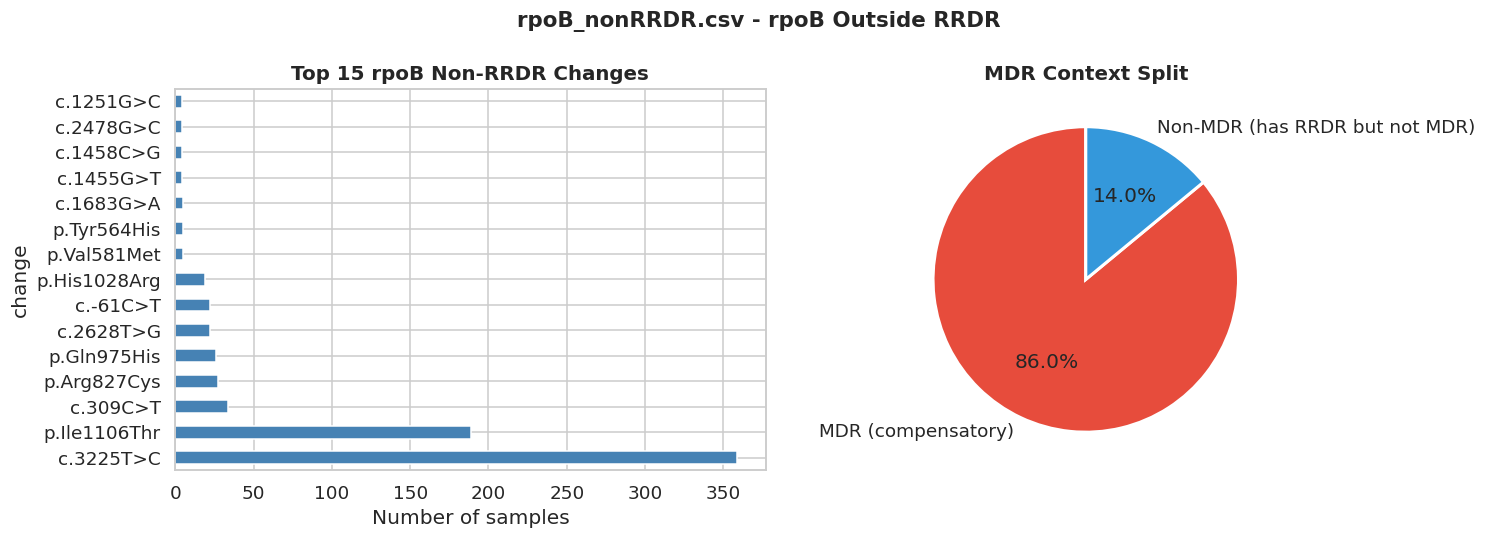

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rpob['change'].value_counts().head(15).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 rpoB Non-RRDR Changes', fontweight='bold')
axes[0].set_xlabel('Number of samples')

rpob['sample_MDR'].map({1:'MDR (compensatory)',0:'Non-MDR (has RRDR but not MDR)'}).value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=['#e74c3c','#3498db'],
    startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('MDR Context Split', fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('rpoB_nonRRDR.csv - rpoB Outside RRDR', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


---
### 8. variant_metadata.csv - genomic Position Lookup Table

#### What is it?
Maps each variant ID (column name in feature matrix) to its genomic coordinates 
on H37Rv. The **column annotation** for the feature matrix.

#### Used for:
- Annotating SHAP feature importance with gene names
- Filtering variants by genomic region
- Connecting feature matrix columns to biological meaning


In [50]:

vm = pd.read_csv(VAR_META_PATH)
print(f"Shape: {vm.shape}")
print(f"\nFirst 10 rows:")
print(vm.head(10).to_string(index=False))
print()
print(f"POS range: {vm['POS'].min()} — {vm['POS'].max()} bp (H37Rv = 4,411,532 bp total)")
snp  = ((vm['REF'].str.len()==1) & (~vm['ALT'].str.contains(',',na=False)) & (vm['ALT'].str.len()==1)).sum()
print(f"SNPs: {snp:,} | Indels/multi: {len(vm)-snp:,}")


Shape: (94583, 5)

First 10 rows:
            variant_id      CHROM  POS REF   ALT
     Chromosome_30_C_G Chromosome   30   C     G
     Chromosome_42_C_T Chromosome   42   C     T
   Chromosome_51_C_T,A Chromosome   51   C   T,A
    Chromosome_187_T_C Chromosome  187   T     C
  Chromosome_189_A_G,C Chromosome  189   A   G,C
    Chromosome_207_T_C Chromosome  207   T     C
    Chromosome_219_A_G Chromosome  219   A     G
    Chromosome_225_G_A Chromosome  225   G     A
    Chromosome_246_T_C Chromosome  246   T     C
Chromosome_255_T_G,C,A Chromosome  255   T G,C,A

POS range: 30 — 4411106 bp (H37Rv = 4,411,532 bp total)
SNPs: 66,446 | Indels/multi: 28,137


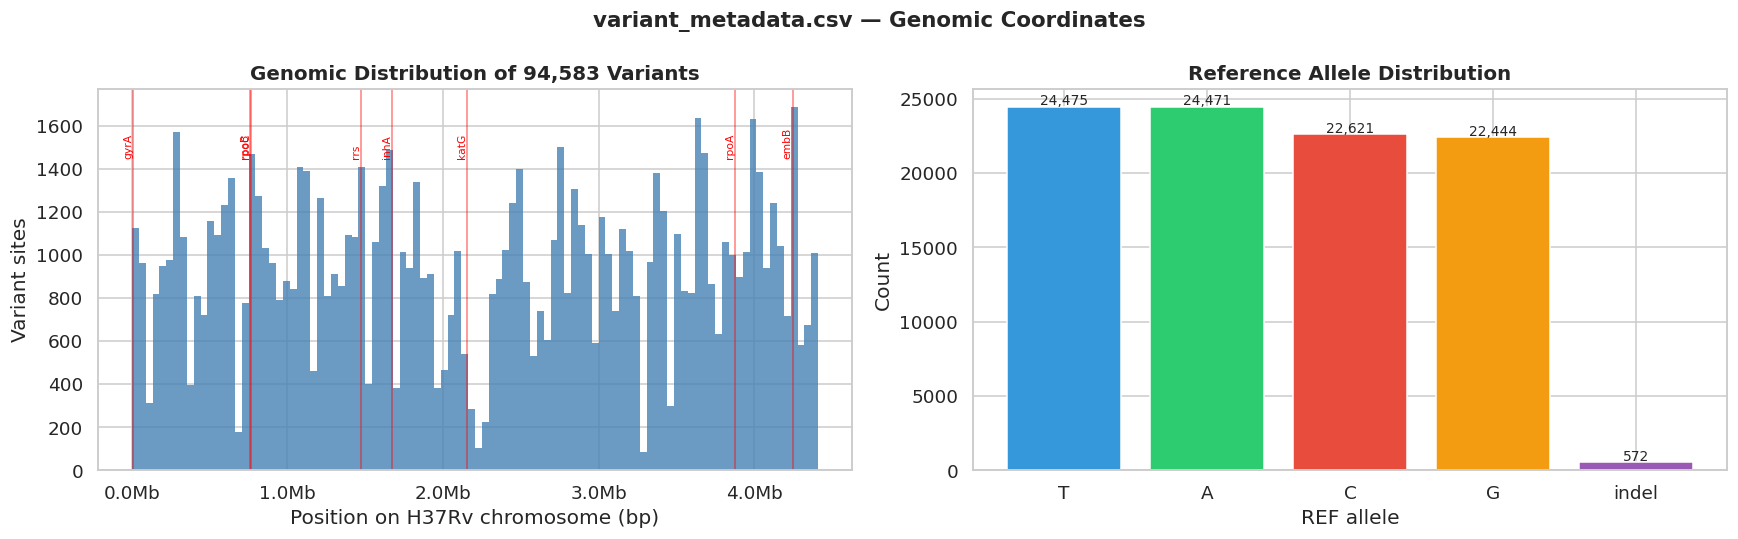

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(vm['POS'], bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Position on H37Rv chromosome (bp)')
axes[0].set_ylabel('Variant sites')
axes[0].set_title('Genomic Distribution of 94,583 Variants', fontweight='bold')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}Mb'))

gene_pos = {'rpoB':759807,'katG':2153889,'inhA':1674202,'gyrA':7302,
            'embB':4246514,'rrs':1472830,'rpoC':762507,'rpoA':3877464}
ymax = axes[0].get_ylim()[1]
for gene, pos in gene_pos.items():
    axes[0].axvline(pos, color='red', alpha=0.5, linewidth=1)
    axes[0].text(pos, ymax*0.82, gene, rotation=90, fontsize=7, color='red', ha='right')

ref_dist = vm['REF'].apply(lambda x: x if len(x)==1 else 'indel').value_counts()
axes[1].bar(ref_dist.index, ref_dist.values,
            color=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6'])
axes[1].set_title('Reference Allele Distribution', fontweight='bold')
axes[1].set_xlabel('REF allele')
axes[1].set_ylabel('Count')
for i, v in enumerate(ref_dist.values):
    axes[1].text(i, v+100, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('variant_metadata.csv — Genomic Coordinates', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


---
### 9. other_variants.csv - All Non-DR Variants from TB-Profiler

#### What is it?
Every variant TB-Profiler found that is NOT a known DR mutation. 263,288 records.
Includes synonymous variants, upstream regulatory variants, and the subset 
flagged as compensatory candidates.


In [ ]:
other = pd.read_csv(OTHER_PATH)
print(f"Shape: {other.shape}")
comp_split = other['is_compensatory_candidate'].value_counts()
print(f"\nCompensatory candidate split:")
for v, cnt in comp_split.items():
    print(f"  is_compensatory_candidate={v}: {cnt:>7,} ({cnt/len(other)*100:.1f}%)  ← {'compensatory set' if v==1 else 'background'}")
print()
print("Variant type distribution:")
for vtype, cnt in other['type'].value_counts().head(8).items():
    print(f"  {vtype:<45}: {cnt:>6,} ({cnt/len(other)*100:.1f}%)")


Shape: (263288, 21)

Compensatory candidate split:
  is_compensatory_candidate=0: 238,570 (90.6%)  ← background
  is_compensatory_candidate=1:  24,718 (9.4%)  ← compensatory set

Variant type distribution:
  synonymous_variant                           : 145,957 (55.4%)
  upstream_gene_variant                        : 51,616 (19.6%)
  missense_variant                             : 44,425 (16.9%)
  non_coding_transcript_exon_variant           : 20,810 (7.9%)
  frameshift_variant                           :    344 (0.1%)
  stop_gained                                  :     52 (0.0%)
  disruptive_inframe_insertion                 :     29 (0.0%)
  splice_region_variant&stop_retained_variant  :     19 (0.0%)


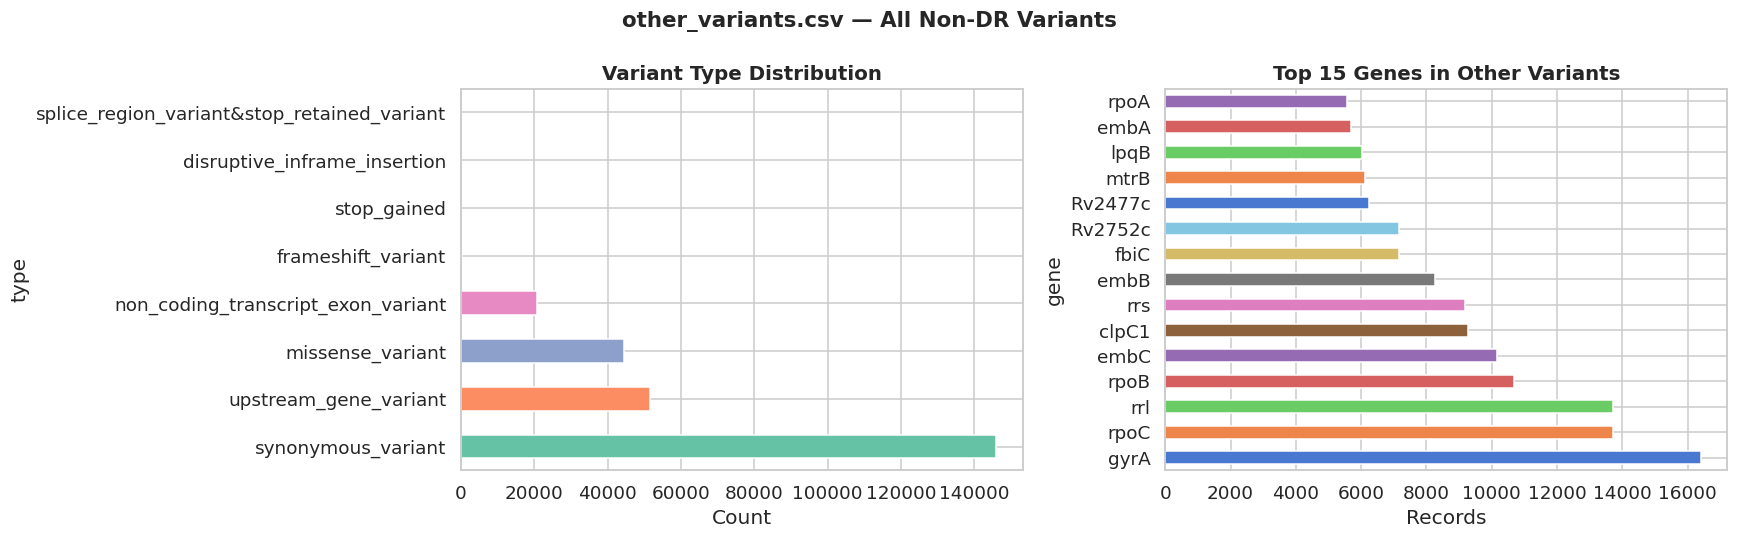

In [53]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

other['type'].value_counts().head(8).plot.barh(
    ax=axes[0], color=sns.color_palette('Set2',8))
axes[0].set_title('Variant Type Distribution', fontweight='bold')
axes[0].set_xlabel('Count')

other['gene'].value_counts().head(15).plot.barh(
    ax=axes[1], color=sns.color_palette('muted',15))
axes[1].set_title('Top 15 Genes in Other Variants', fontweight='bold')
axes[1].set_xlabel('Records')

plt.suptitle('other_variants.csv — All Non-DR Variants', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


In [56]:
print("ALL 9 FILES — COMPLETE SUMMARY")

npz_data = np.load(NPZ_PATH, allow_pickle=True)
labels   = pd.read_csv(LABELS_PATH)
dr       = pd.read_csv(DR_PATH)
comp     = pd.read_csv(COMP_PATH)
rpob     = pd.read_csv(RPOB_PATH)
other    = pd.read_csv(OTHER_PATH)
vm       = pd.read_csv(VAR_META_PATH)

with gzip.open(GT_PATH, 'rt') as f:
    gt_header = f.readline().split('\t')
    gt_rows = sum(1 for _ in f)

with open(CSV_PATH) as f:
    csv_header = f.readline().split(',')
    csv_rows = sum(1 for _ in f)

summary = [
    ('gt_matrix.tsv.gz',           f'{gt_rows:,} variants × {len(gt_header)-1} samples',      'Raw genotype strings (0/0, 1/1) — direct bcftools output'),
    ('variant_matrix_filtered.csv', f'{csv_rows} samples × {len(csv_header)-1:,} variants',   'Binary 0/1 CSV — MAF filtered, has malformed cols'),
    ('feature_matrix.npz',         f"{npz_data['matrix'].shape[0]} × {npz_data['matrix'].shape[1]:,}", 'Clean binary matrix — malformed cols removed, ML ready'),
    ('variant_metadata.csv',       f'{len(vm):,} variants × 5 cols',                          'CHROM/POS/REF/ALT lookup for feature matrix columns'),
    ('labels.csv',                 f'{len(labels)} samples × {labels.shape[1]} cols',         'Drug resistance ground truth — ML targets'),
    ('dr_variants.csv',            f'{len(dr):,} records | {dr["sample_id"].nunique()} samples', 'Known primary resistance mutations'),
    ('compensatory.csv',           f'{len(comp):,} records | {comp[comp["sample_MDR"]==1].shape[0]:,} in MDR', 'Candidate compensatory mutations'),
    ('rpoB_nonRRDR.csv',           f'{len(rpob):,} records | {rpob[rpob["sample_MDR"]==1].shape[0]} in MDR', 'rpoB outside RRDR — special compensatory category'),
    ('other_variants.csv',         f'{len(other):,} records',                                  'All non-DR variants — background + compensatory superset'),
]

for fname, size, desc in summary:
    print(f"\n  {fname}")
    print(f"     Size : {size}")
    print(f"     Role : {desc}")




ALL 9 FILES — COMPLETE SUMMARY

  gt_matrix.tsv.gz
     Size : 94,583 variants × 1857 samples
     Role : Raw genotype strings (0/0, 1/1) — direct bcftools output

  variant_matrix_filtered.csv
     Size : 1857 samples × 126,856 variants
     Role : Binary 0/1 CSV — MAF filtered, has malformed cols

  feature_matrix.npz
     Size : 1858 × 94,583
     Role : Clean binary matrix — malformed cols removed, ML ready

  variant_metadata.csv
     Size : 94,583 variants × 5 cols
     Role : CHROM/POS/REF/ALT lookup for feature matrix columns

  labels.csv
     Size : 1858 samples × 49 cols
     Role : Drug resistance ground truth — ML targets

  dr_variants.csv
     Size : 14,734 records | 1147 samples
     Role : Known primary resistance mutations

  compensatory.csv
     Size : 24,718 records | 7,224 in MDR
     Role : Candidate compensatory mutations

  rpoB_nonRRDR.csv
     Size : 1,335 records | 1148 in MDR
     Role : rpoB outside RRDR — special compensatory category

  other_variants.cs